In [5]:
import pandas as pd
import numpy as np

Ue = 50e-3 # peak voltage

def calcBode(df):
    df['A'] = 20 * np.log10(df['Ua'] / Ue)
    df['phi'] = 360*df['f']*df['DeltaT']
    return df

df_I = calcBode(pd.read_csv("./data/BodeI.csv"))
df_NI = calcBode(pd.read_csv("./data/BodeNI.csv"))

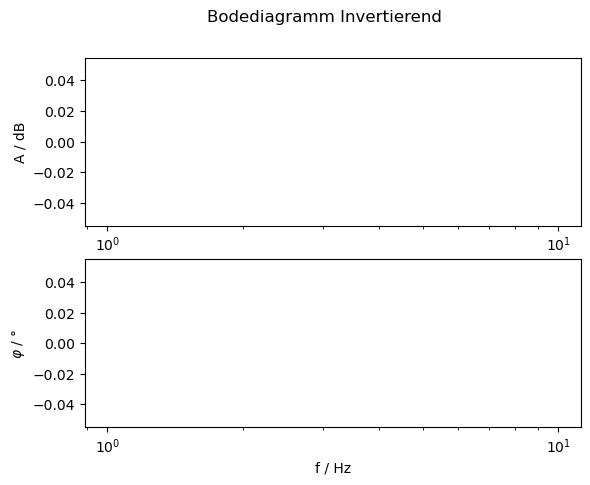

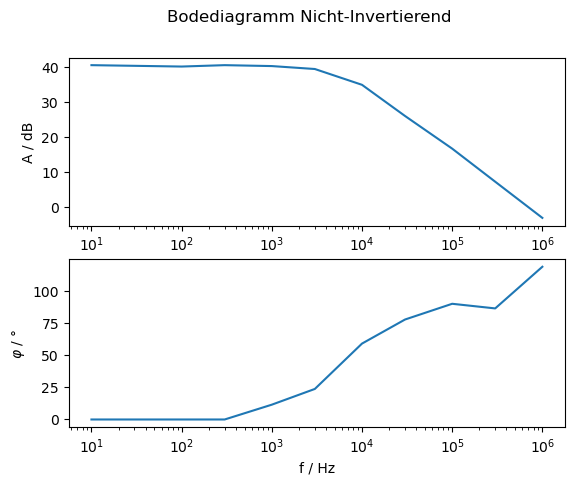

In [6]:
import matplotlib.pyplot as plt

def plot_bode(df):
    fig, (ax_abs, ax_arg) = plt.subplots(nrows=2, ncols=1)
    ax_abs.set_ylabel("A / dB")
    ax_abs.set_xscale('log')
    ax_abs.plot(df['f'], df['A'])

    ax_arg.set_xscale('log')
    ax_arg.set_xlabel("f / Hz")
    ax_arg.set_ylabel("$\\varphi$ / °")
    ax_arg.plot(df['f'], df['phi'])

    return fig

fig_I = plot_bode(df_I)
fig_I.suptitle('Bodediagramm Invertierend')
fig_I.savefig("./latex/images/bode_I.png")
fig_NI = plot_bode(df_NI)
fig_NI.suptitle('Bodediagramm Nicht-Invertierend')
fig_NI.savefig("./latex/images/bode_NI.png")


In [7]:
data = df_I.merge(df_NI, on='f', suffixes=('_I', '_NI') )
data

,f,Ua_I,DeltaT_I,A_I,phi_I,Ua_NI,DeltaT_NI,A_NI,phi_NI
0,10,NaN,NaN,NaN,NaN,5.3600,0.000000e+00,40.603896,0.00
1,100,NaN,NaN,NaN,NaN,5.1200,0.000000e+00,40.205999,0.00
2,300,NaN,NaN,NaN,NaN,5.3600,0.000000e+00,40.603896,0.00
3,1000,NaN,NaN,NaN,NaN,5.2000,3.200000e-05,40.340667,11.52
4,3000,NaN,NaN,NaN,NaN,4.7200,2.200000e-05,39.499440,23.76
5,10000,NaN,NaN,NaN,NaN,2.8000,1.640000e-05,34.963761,59.04
6,30000,NaN,NaN,NaN,NaN,1.0000,7.200000e-06,26.020600,77.76
7,100000,NaN,NaN,NaN,NaN,0.3400,2.500000e-06,16.650178,90.00
8,300000,NaN,NaN,NaN,NaN,0.1140,8.000000e-07,7.158697,86.40
9,1000000,NaN,NaN,NaN,NaN,0.0345,3.300000e-07,-3.223018,118.80


In [8]:
latex = data.to_latex(
    index=False,
    formatters={
        'f': "{:.0e}".format
    }
)
print(latex)

\begin{tabular}{rrrrrrrrr}
\toprule
f & Ua_I & DeltaT_I & A_I & phi_I & Ua_NI & DeltaT_NI & A_NI & phi_NI \\
\midrule
1e+01 & NaN & NaN & NaN & NaN & 5.360000 & 0.000000 & 40.603896 & 0.000000 \\
1e+02 & NaN & NaN & NaN & NaN & 5.120000 & 0.000000 & 40.205999 & 0.000000 \\
3e+02 & NaN & NaN & NaN & NaN & 5.360000 & 0.000000 & 40.603896 & 0.000000 \\
1e+03 & NaN & NaN & NaN & NaN & 5.200000 & 0.000032 & 40.340667 & 11.520000 \\
3e+03 & NaN & NaN & NaN & NaN & 4.720000 & 0.000022 & 39.499440 & 23.760000 \\
1e+04 & NaN & NaN & NaN & NaN & 2.800000 & 0.000016 & 34.963761 & 59.040000 \\
3e+04 & NaN & NaN & NaN & NaN & 1.000000 & 0.000007 & 26.020600 & 77.760000 \\
1e+05 & NaN & NaN & NaN & NaN & 0.340000 & 0.000003 & 16.650178 & 90.000000 \\
3e+05 & NaN & NaN & NaN & NaN & 0.114000 & 0.000001 & 7.158697 & 86.400000 \\
1e+06 & NaN & NaN & NaN & NaN & 0.034500 & 0.000000 & -3.223018 & 118.800000 \\
3e+06 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
\bottomrule
\end{tabular}

